In [1]:
## UPDATED MARKOWITZ MODEL (PORTFOLIO RISK CAL UPDATED)

import numpy as np
import pandas as pd
import cvxpy as cp

# ----------------------------------------------------
# 1. LOAD RETURN, COVARIANCE, TICKERS
# ----------------------------------------------------

mu = np.load("mu_annual.npy")        # (n,)
cov = np.load("cov_annual.npy")      # (n, n)
tickers = pd.read_csv("tickers.csv", header=None)[0].astype(str).tolist()

# FIX: drop the index row if it exists
if tickers[0].strip() == "0":
    tickers = tickers[1:]

n = len(mu)

# Ensure covariance is valid
cov = 0.5 * (cov + cov.T)
eps = 1e-8
cov = cov + eps * np.eye(n)

assert cov.shape == (n, n), f"Expected {n}x{n} covariance, got {cov.shape}"

# --- GLOBAL CONSTRAINTS ---

MAX_WEIGHT = 1   # <-- applies to ALL profiles

# ----------------------------------------------------
# 2. PROFILE-SPECIFIC PARAMETERS
# ----------------------------------------------------

profile_params = {
    "Aggressive": {
        "max_vol": 0.45,
        "max_corr_score": 0.55,
    },
    "Balanced": {
        "max_vol": 0.25,
        "max_corr_score": 0.45,
    },
    "Conservative": {
        "max_vol": 0.18,
        "max_corr_score": 0.35,
    }
}

# ----------------------------------------------------
# 3. BUILD CORRELATION MATRIX
# ----------------------------------------------------
sigma_vec = np.sqrt(np.diag(cov))        

with np.errstate(divide="ignore", invalid="ignore"):
    denom = np.outer(sigma_vec, sigma_vec)
    corr_mat = cov / denom
    corr_mat[~np.isfinite(corr_mat)] = 0.0

np.fill_diagonal(corr_mat, 1.0)
corr_mat = 0.5 * (corr_mat + corr_mat.T)
corr_mat = corr_mat + eps * np.eye(n)

# ----------------------------------------------------
# 4. OPTIMIZER
# ----------------------------------------------------
def max_return_low_corr_markowitz(mu, cov, corr_mat,
                                  max_vol,
                                  max_corr_score,
                                  max_weight): 

    n = len(mu)
    w = cp.Variable(n)

    port_var = cp.quad_form(w, cov)
    corr_score_expr = cp.quad_form(w, corr_mat)

    objective = cp.Maximize(mu @ w) ## Objective Function

    constraints = [
        cp.sum(w) == 1, # Full Investment
        w >= 0,         # No Short Selling
        w <= max_weight, # Max Weight Constraint
        port_var <= max_vol**2, # Max Volatility Constraint
        corr_score_expr <= max_corr_score, # Max Correlation Score Constraint   
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve()

    if (w.value is None) or (prob.status not in ["optimal", "optimal_inaccurate"]):
        raise RuntimeError(f"Quadratic optimization failed: {prob.status}")

    w_opt = np.array(w.value).flatten()
    port_return = float(mu @ w_opt)
    port_vol = float(np.sqrt(w_opt @ cov @ w_opt))
    port_corr = float(w_opt @ corr_mat @ w_opt)

    return w_opt, port_return, port_vol, port_corr


# ----------------------------------------------------
# 5. RUN OPTIMIZER
# ----------------------------------------------------
results = {}

for profile, params in profile_params.items():

    w, ret, vol, corr_q = max_return_low_corr_markowitz(
        mu, cov, corr_mat,
        max_vol=params["max_vol"],
        max_corr_score=params["max_corr_score"],
        max_weight=MAX_WEIGHT   # <-- global constraint
    )

    df = pd.DataFrame({"Ticker": tickers, "Weight": w}).sort_values("Weight", ascending=False).round({"Weight": 4})

    print("\n=========================================")
    print(f"PORTFOLIO OPTIMIZATION – {profile}")
    print("=========================================")
    print(f"Return (mu^T w):          {ret: .2%}")
    print(f"Volatility (sqrt wΣw):    {vol: .2%} (limit {params['max_vol']: .0%})")
    print(f"CorrScore (w^T C w):      {corr_q: .2f} (limit {params['max_corr_score']: .2f})\n")

    print(df[df["Weight"] > 0.001])

    results[profile] = {
        "weights": w,
        "return": ret,
        "vol": vol,
        "corr": corr_q
    }


PORTFOLIO OPTIMIZATION – Aggressive
Return (mu^T w):           78.06%
Volatility (sqrt wΣw):     36.04% (limit  45%)
CorrScore (w^T C w):       0.55 (limit  0.55)

   Ticker  Weight
22   NVDA  0.5443
6     CEG  0.2153
17    LLY  0.1087
10     GE  0.0670
30   WELL  0.0647

PORTFOLIO OPTIMIZATION – Balanced
Return (mu^T w):           64.17%
Volatility (sqrt wΣw):     25.00% (limit  25%)
CorrScore (w^T C w):       0.43 (limit  0.45)

   Ticker  Weight
10     GE  0.2940
22   NVDA  0.2678
30   WELL  0.1749
17    LLY  0.1720
6     CEG  0.0913

PORTFOLIO OPTIMIZATION – Conservative
Return (mu^T w):           49.52%
Volatility (sqrt wΣw):     18.00% (limit  18%)
CorrScore (w^T C w):       0.34 (limit  0.35)

   Ticker  Weight
30   WELL  0.2287
10     GE  0.1891
31    WMT  0.1885
17    LLY  0.1454
22   NVDA  0.1291
1    ABBV  0.0717
6     CEG  0.0475


In [2]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Load correlation matrix and tickers
# cov = np.load("cov_annual.npy")
# tickers = pd.read_csv("tickers.csv", header=None)[0].tolist()

# # Convert covariance → correlation matrix
# sigma = np.sqrt(np.diag(cov))
# corr_mat = cov / np.outer(sigma, sigma)

# plt.figure(figsize=(12,10))
# plt.imshow(corr_mat, cmap='coolwarm', vmin=-1, vmax=1)
# plt.colorbar(label="Correlation")
# plt.xticks(range(len(tickers)), tickers, rotation=90)
# plt.yticks(range(len(tickers)), tickers)
# plt.title("Asset Correlation Matrix")
# plt.tight_layout()
# plt.show()


In [3]:
# import matplotlib.pyplot as plt

# profiles = list(results.keys())
# rets  = [results[p]["ret"]  for p in profiles]
# vols  = [results[p]["vol"]  for p in profiles]
# corrs = [results[p]["corr"] for p in profiles]

# # ---- Scatter Plot ----
# plt.figure(figsize=(8,6))
# plt.scatter(vols, rets, s=300, c=corrs, cmap="coolwarm", edgecolors='black')

# for i, label in enumerate(profiles):
#     plt.text(vols[i] + 0.002, rets[i] + 0.005, label, fontsize=12)

# cbar = plt.colorbar()
# cbar.set_label("CorrScore (wᵀ C w)")

# plt.xlabel("Volatility (σ)")
# plt.ylabel("Expected Return")
# plt.title("Risk–Return–Correlation Tradeoff")
# plt.grid(True)
# plt.show()


In [4]:
# # APPENDIX: Markowitz Model 2: 1 STOCK PER SECTOR CONSTRAINT

# import numpy as np
# import pandas as pd
# import cvxpy as cp

# # ====================================================
# # 0. PARAMETERS (easy to tune here)
# # ====================================================
# MAX_WEIGHT_PER_STOCK = 1        # cap on individual stock weight
# MIN_SECTOR_WEIGHT    = 0.01        # ensures ≥1 stock per sector (1% minimum)
# EPSILON              = 1e-8        # numerical stability

# RISK_LIMITS = {
#     "Aggressive_LC":    0.45,
#     "Balanced_LC":      0.25,
#     "Conservative_LC":  0.18,
# }

# CORR_LIMITS = {
#     "Aggressive_LC":    0.55,
#     "Balanced_LC":      0.45,
#     "Conservative_LC":  0.35,
# }

# # ====================================================
# # 1. LOAD DATA
# # ====================================================
# mu = np.load("mu_annual.npy")
# cov = np.load("cov_annual.npy")
# tickers = pd.read_csv("tickers.csv", header=None)[0].astype(str).tolist()

# # Remove accidental index row if present
# if tickers[0].strip() == "0":
#     tickers = tickers[1:]

# n = len(mu)
# assert cov.shape == (n, n), f"Expected {n}x{n}, got {cov.shape}"

# # Load sector map from sp500_sectors.csv

# sector_df = pd.read_csv("../data/sp500_sectors.csv")
# sector_map = sector_df.set_index("Symbol")["Sector"]

# # Align sectors to tickers
# sectors = [sector_map[t] for t in tickers]
# unique_sectors = sorted(set(sectors))

# # ====================================================
# # 2. BUILD CORRELATION MATRIX
# # ====================================================
# cov = 0.5 * (cov + cov.T)            # symmetrize
# cov += EPSILON * np.eye(n)           # regularize

# sigma_vec = np.sqrt(np.diag(cov))
# denom = np.outer(sigma_vec, sigma_vec)

# with np.errstate(divide="ignore", invalid="ignore"):
#     corr_mat = cov / denom
#     corr_mat[~np.isfinite(corr_mat)] = 0.0

# np.fill_diagonal(corr_mat, 1.0)
# corr_mat = 0.5 * (corr_mat + corr_mat.T)
# corr_mat += EPSILON * np.eye(n)

# # ====================================================
# # 3. OPTIMIZER FUNCTION
# # ====================================================
# def solve_portfolio(mu, cov, corr_mat, max_vol, max_corr, max_weight):
#     w = cp.Variable(n)

#     # Objective: maximize expected return
#     objective = cp.Maximize(mu @ w)

#     # Main constraints
#     constraints = [
#         cp.sum(w) == 1,
#         w >= 0,
#         w <= max_weight,
#         cp.quad_form(w, cov) <= max_vol**2,
#         cp.quad_form(w, corr_mat) <= max_corr,
#     ]

#     # Sector constraint: ensure ≥1 stock per sector
#     for sector in unique_sectors:
#         idx = [i for i, s in enumerate(sectors) if s == sector]
#         constraints.append(cp.sum(w[idx]) >= MIN_SECTOR_WEIGHT)

#     # Solve model
#     prob = cp.Problem(objective, constraints)
#     prob.solve()

#     if w.value is None:
#         raise RuntimeError(f"Optimization failed: {prob.status}")

#     w_opt = np.array(w.value).flatten()
#     ret = float(mu @ w_opt)
#     vol = float(np.sqrt(w_opt @ cov @ w_opt))
#     corr_score = float(w_opt @ corr_mat @ w_opt)

#     return w_opt, ret, vol, corr_score

# # ====================================================
# # 4. RUN OPPTIMIZER FOR EACH PROFILE
# # ====================================================
# results = {}

# for profile in RISK_LIMITS:
#     max_vol  = RISK_LIMITS[profile]
#     max_corr = CORR_LIMITS[profile]

#     w, ret, vol, corr = solve_portfolio(
#         mu, cov, corr_mat,
#         max_vol=max_vol,
#         max_corr=max_corr,
#         max_weight=MAX_WEIGHT_PER_STOCK
#     )

#     df = pd.DataFrame({"Ticker": tickers, "Weight": w})
#     df = df[df["Weight"] > 0.001].sort_values("Weight", ascending=False)

#     print("\n=========================================")
#     print(f"MARKOWITZ MODEL – {profile}")
#     print("=========================================")
#     print(f"Return:     {ret: .2%}")
#     print(f"Vol:        {vol: .2%} (limit {max_vol: .2%})")
#     print(f"CorrScore:  {corr: .4f} (limit {max_corr: .4f})")
#     print(df)

#     results[profile] = {"w": w, "ret": ret, "vol": vol, "corr": corr}


In [5]:
# ----------------------------------------------------
# SENSITIVITY ANALYSIS
# ----------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Wrapper function to handle infeasible cases

def safe_optimize(max_vol, max_corr_score, max_weight):
    """
    Wrapper around max_return_low_corr_markowitz that
    returns NaNs instead of blowing up when the problem is infeasible.
    """
    try:
        w, ret, vol, corr_q = max_return_low_corr_markowitz(
            mu, cov, corr_mat,
            max_vol=max_vol,
            max_corr_score=max_corr_score,
            max_weight=max_weight
        )
        return w, ret, vol, corr_q
    except Exception:
        n = len(mu)
        return np.full(n, np.nan), np.nan, np.nan, np.nan


# ----------------------------------------------------
# GLOBAL RANGES FOR THE THREE KNOBS
# ----------------------------------------------------
max_vol_grid    = np.linspace(0.15, 0.5, 20)   # risk cap
max_corr_grid   = np.linspace(0.10, 1, 20)   # corr_score cap
max_weight_grid = np.linspace(0.20, 1, 20)   # max_weight cap

# A baseline point in the middle-ish of the ranges

BASE_SETTINGS = {
    "max_vol": 0.5,
    "max_corr_score": 0.55,
    "max_weight": 0.75,
}

# ----------------------------------------------------
# SENSITIVITY FUNCTION
# ----------------------------------------------------

def run_sensitivity(
    param_name,              # "max_vol" OR "max_weight" OR "max_corr_score"
    grid_values,             # e.g. max_weight_grid
    BASE_SETTINGS=BASE_SETTINGS
):
    rows = []
    weights_list = []

    # Loop over the parameter grid
    for v in grid_values:
        params = BASE_SETTINGS.copy()
        params[param_name] = v
        
        w, ret, vol, corr = safe_optimize(
            max_vol=params["max_vol"],
            max_corr_score=params["max_corr_score"],
            max_weight=params["max_weight"]
        )

        rows.append([v, ret, vol, corr])
        weights_list.append(w)

    # Build dataframe
    df = pd.DataFrame(
        rows,
        columns=[f"{param_name}_limit", "return", "actual_vol", "corr_score"]
    )

    return df, weights_list

In [6]:
# ----------------------------------------------------
# RISK (max_vol) SENSITIVITY
# ----------------------------------------------------

df_risk, weights_risk = run_sensitivity(
    param_name="max_vol",
    grid_values=max_vol_grid
)

df_risk["max_weight_used"] = [np.nanmax(w) for w in weights_risk]

# ===============================================
# PLATEAU DETECTION (point where return stops increasing meaningfully)
# ===============================================

tol = 1e-4  # small tolerance

returns = df_risk["return"].values
max_return = np.nanmax(returns)

plateau_indices = np.where(max_return - returns <= tol)[0]

if len(plateau_indices) > 0:
    plateau_vol = df_risk["max_vol_limit"].iloc[plateau_indices[0]]
else:
    plateau_vol = np.nan



In [7]:
print(f"""
=================== RISK SENSITIVITY ===================

Baseline constraints:
  max_corr_score = {BASE_SETTINGS['max_corr_score']:.2f}
  max_weight     = {BASE_SETTINGS['max_weight']:.2f}

Plateau return: {max_return:.4f}
Plateau starts at max_vol ≈ {plateau_vol:.3f}

Sensitivity table:
{df_risk.round(4).to_string(index=False)}
""")



=================== RISK SENSITIVITY ===================

Baseline constraints:
  max_corr_score = 0.55
  max_weight     = 0.75

Plateau return: 0.7806
Plateau starts at max_vol ≈ 0.371

Sensitivity table:
 max_vol_limit  return  actual_vol  corr_score  max_weight_used
        0.1500  0.4033      0.1500      0.3070           0.1928
        0.1684  0.4628      0.1684      0.3252           0.2117
        0.1868  0.5130      0.1868      0.3493           0.2319
        0.2053  0.5560      0.2053      0.3723           0.2370
        0.2237  0.5939      0.2237      0.3945           0.2618
        0.2421  0.6282      0.2421      0.4194           0.2856
        0.2605  0.6587      0.2605      0.4387           0.3046
        0.2789  0.6864      0.2789      0.4661           0.3346
        0.2974  0.7125      0.2974      0.5004           0.3736
        0.3158  0.7373      0.3158      0.5382           0.4134
        0.3342  0.7602      0.3342      0.5500           0.4678
        0.3526  0.7774   

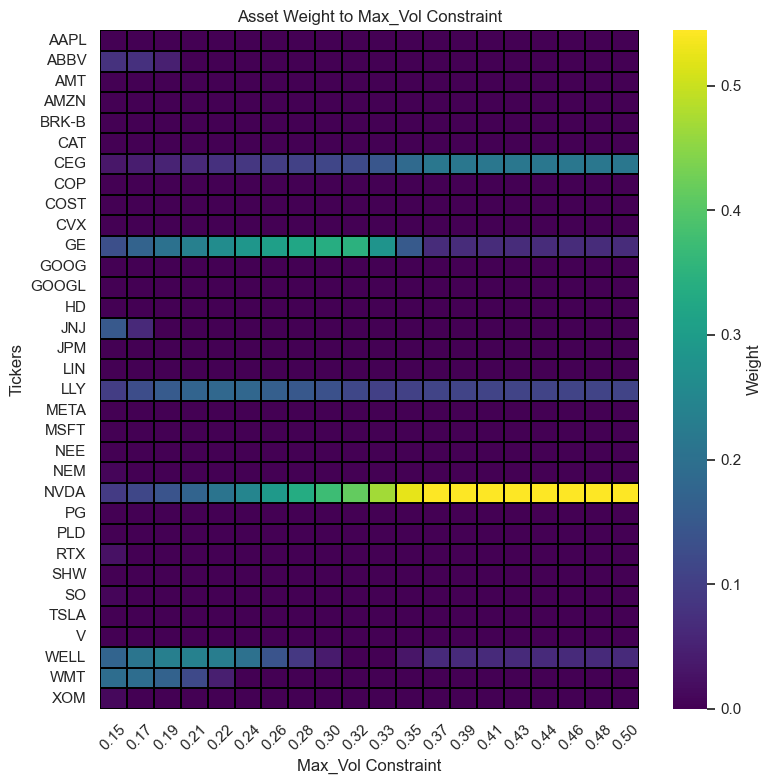

In [8]:
# ----------------------------------------------------
# Standalone Heatmap for Risk Sensitivity (max_vol)
# ----------------------------------------------------

# use the weights list produced earlier (weights_risk)
weight_df = pd.DataFrame(weights_risk, columns=tickers)
weight_df["max_vol_limit"] = max_vol_grid
weight_df = weight_df.set_index("max_vol_limit")

plt.figure(figsize=(8, 8))
sns.heatmap(
    weight_df.T,
    cmap="viridis",
    cbar_kws={"label": "Weight"},
    linewidths=0.2,
    linecolor="black"
)

plt.title("Asset Weight to Max_Vol Constraint")
plt.xlabel("Max_Vol Constraint")
plt.ylabel("Tickers")

# Format x-axis with 2-decimal labels
plt.gca().set_xticklabels([f"{x:.2f}" for x in weight_df.index], rotation=45)

plt.tight_layout()
plt.show()



In [9]:
# # ===============================================
# # BINDING CONSTRAINTS DETECTION
# # ===============================================
# binding = []

# for i, row in df_risk.iterrows():
#     v        = row["max_vol_limit"]
#     ret      = row["return"]
#     act_vol  = row["actual_vol"]
#     corr     = row["corr_score"]

#     reasons = []

#     # 1. Risk constraint binding
#     if not np.isnan(act_vol) and abs(act_vol - v) < 1e-4:
#         reasons.append("risk")

#     # 2. Correlation constraint binding
#     if not np.isnan(corr) and abs(corr - BASE_SETTINGS["max_corr_score"]) < 1e-4:
#         reasons.append("corr")

#     # 3. Weight constraint binding
#     if np.any(np.isclose(w, BASE_SETTINGS["max_weight"], atol=1e-4)):
#         reasons.append("weight")

#     binding.append(", ".join(reasons) if reasons else "none")

# df_risk["binding_constraint"] = binding

# print("\n========= Binding Constraints =========")
# print(df_risk[["max_vol_limit", "binding_constraint"]])


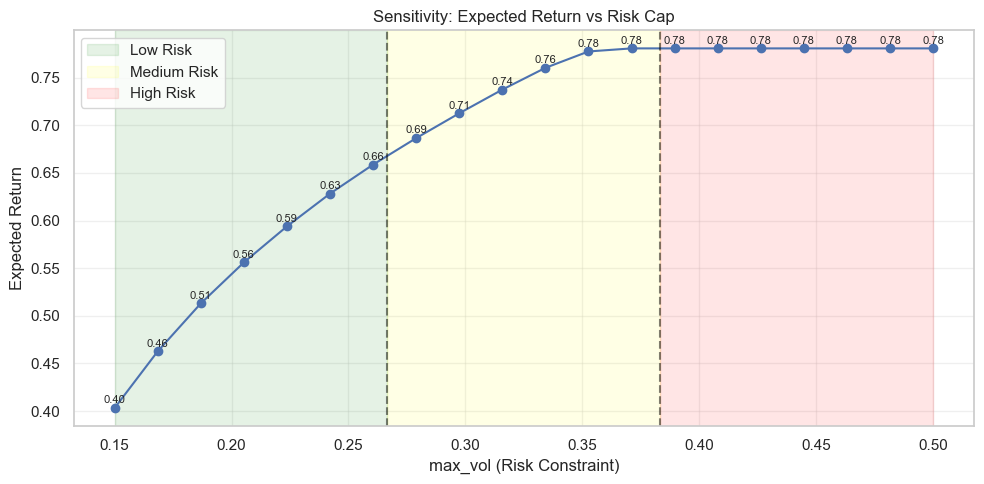

In [10]:
# ===============================================
# PLOT: RETURN VS RISK CAP
# ===============================================

low_end   = max_vol_grid.min()
high_end  = max_vol_grid.max()
cut1 = low_end + (high_end - low_end)/3
cut2 = low_end + 2*(high_end - low_end)/3

plt.figure(figsize=(10,5))

# Plot curve
plt.plot(df_risk["max_vol_limit"], df_risk["return"], marker="o")

# Add numbers on each dot
for x, y in zip(df_risk["max_vol_limit"], df_risk["return"]):
    if not np.isnan(y):
        plt.text(x, y + 0.005, f"{y:.2f}", ha="center", fontsize=8)

# Shade sectors
plt.axvspan(low_end, cut1, color="green", alpha=0.10, label="Low Risk")
plt.axvspan(cut1, cut2, color="yellow", alpha=0.10, label="Medium Risk")
plt.axvspan(cut2, high_end, color="red", alpha=0.10, label="High Risk")

# Sector boundaries
plt.axvline(cut1, color="black", linestyle="--", alpha=0.5)
plt.axvline(cut2, color="black", linestyle="--", alpha=0.5)

plt.title("Sensitivity: Expected Return vs Risk Cap")
plt.xlabel("max_vol (Risk Constraint)")
plt.ylabel("Expected Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ----------------------------------------------------
# MAX WEIGHT (max_weight) SENSITIVITY
# ----------------------------------------------------
df_weight, weights_weight = run_sensitivity(
    param_name="max_weight",
    grid_values=max_weight_grid
)

# -------- Plateau Detection --------
returns = df_weight["return"].values
max_return = np.nanmax(returns)
tol = 1e-4

plateau_index = np.where(max_return - returns <= tol)[0]
plateau_weight = (
    df_weight["max_weight_limit"].iloc[plateau_index[0]]
    if len(plateau_index) > 0 else np.nan
)

print(f"""
=================== MAX WEIGHT SENSITIVITY ===================

Baseline constraints:
  max_vol        = {BASE_SETTINGS['max_vol']:.2f}
  max_corr_score = {BASE_SETTINGS['max_corr_score']:.2f}

Plateau return: {max_return:.4f}
Plateau starts at max_weight ≈ {plateau_weight:.3f}

Sensitivity table:
{df_weight.round(4).to_string(index=False)}
""")

# # -------- Binding Detection --------
# binding = []

# for i, row in df_weight.iterrows():
#     weight_limit = row["max_weight_limit"]
#     ret          = row["return"]
#     act_vol      = row["actual_vol"]
#     corr         = row["corr_score"]

#     reasons = []

#     # Risk binding?
#     if not np.isnan(act_vol) and abs(act_vol - BASE_SETTINGS["max_vol"]) < 1e-4:
#         reasons.append("risk")

#     # Corr binding?
#     if not np.isnan(corr) and abs(corr - BASE_SETTINGS["max_corr_score"]) < 1e-4:
#         reasons.append("corr")

#     # Weight binding?
#     w = weights_weight[i]
#     if np.any(np.isclose(w, weight_limit, atol=1e-4)):
#         reasons.append("weight")

#     binding.append(", ".join(reasons) if reasons else "none")

# df_weight["binding_constraint"] = binding

# print("\n========= Binding Constraints (Max Weight Sweep) =========")
# print(df_weight[["max_weight_limit", "binding_constraint"]])



=================== MAX WEIGHT SENSITIVITY ===================

Baseline constraints:
  max_vol        = 0.50
  max_corr_score = 0.55

Plateau return: 0.7806
Plateau starts at max_weight ≈ 0.537

Sensitivity table:
 max_weight_limit  return  actual_vol  corr_score
           0.2000  0.6230      0.2446      0.3980
           0.2421  0.6704      0.2772      0.4459
           0.2842  0.7088      0.3042      0.4964
           0.3263  0.7404      0.3303      0.5500
           0.3684  0.7561      0.3467      0.5500
           0.4105  0.7653      0.3529      0.5500
           0.4526  0.7726      0.3558      0.5500
           0.4947  0.7779      0.3584      0.5500
           0.5368  0.7805      0.3602      0.5500
           0.5789  0.7806      0.3604      0.5500
           0.6211  0.7806      0.3604      0.5500
           0.6632  0.7806      0.3604      0.5500
           0.7053  0.7806      0.3604      0.5500
           0.7474  0.7806      0.3604      0.5500
           0.7895  0.7806      0.3

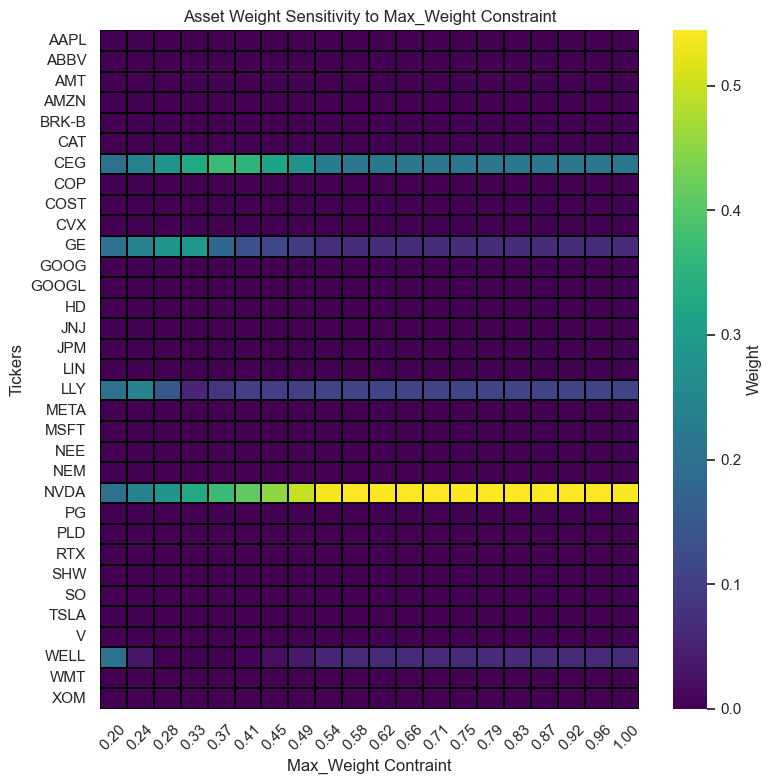

In [12]:
# ----------------------------------------------------
# WEIGHT HEATMAP FOR MAX WEIGHT SENSITIVITY
# ----------------------------------------------------

weight_df = pd.DataFrame(weights_weight, columns=tickers)
weight_df["max_weight_limit"] = max_weight_grid
weight_df = weight_df.set_index("max_weight_limit")

plt.figure(figsize=(8, 8))
sns.heatmap(
    weight_df.T,
    cmap="viridis",
    cbar_kws={"label": "Weight"},
    linewidths=0.2,
    linecolor="black"
)

plt.title("Asset Weight Sensitivity to Max_Weight Constraint")
plt.xlabel("Max_Weight Contraint")
plt.ylabel("Tickers")

# Format x-axis with 2-decimal labels
plt.gca().set_xticklabels([f"{x:.2f}" for x in weight_df.index], rotation=45)

plt.tight_layout()
plt.show()



In [13]:
# ----------------------------------------------------
# CORRELATION SCORE (max_corr_score) SENSITIVITY
# ----------------------------------------------------

df_corr, weights_corr = run_sensitivity(
    param_name="max_corr_score",
    grid_values=max_corr_grid
)

# -------- Plateau Detection --------
returns = df_corr["return"].values
max_return = np.nanmax(returns)
tol = 1e-4

plateau_idx = np.where(max_return - returns <= tol)[0]
plateau_corr = (
    df_corr["max_corr_score_limit"].iloc[plateau_idx[0]]
    if len(plateau_idx) > 0 else np.nan
)

print(f"""
=================== CORR_SCORE SENSITIVITY ===================

Baseline constraints:
  max_vol    = {BASE_SETTINGS['max_vol']:.2f}
  max_weight = {BASE_SETTINGS['max_weight']:.2f}

Plateau return: {max_return:.4f}
Plateau starts at max_corr_score ≈ {plateau_corr:.3f}

Sensitivity table:
{df_corr.round(4).to_string(index=False)}

""")


=================== CORR_SCORE SENSITIVITY ===================

Baseline constraints:
  max_vol    = 0.50
  max_weight = 0.75

Plateau return: 0.8819
Plateau starts at max_corr_score ≈ 0.811

Sensitivity table:
 max_corr_score_limit  return  actual_vol  corr_score
               0.1000     NaN         NaN         NaN
               0.1474     NaN         NaN         NaN
               0.1947     NaN         NaN         NaN
               0.2421  0.4112      0.1867      0.2421
               0.2895  0.5392      0.2227      0.2895
               0.3368  0.6077      0.2563      0.3368
               0.3842  0.6583      0.2830      0.3842
               0.4316  0.6999      0.3066      0.4316
               0.4789  0.7356      0.3282      0.4789
               0.5263  0.7667      0.3488      0.5263
               0.5737  0.7935      0.3713      0.5737
               0.6211  0.8171      0.3916      0.6211
               0.6684  0.8384      0.4103      0.6684
               0.7158  0.8578   

In [14]:
# # ----------------------------------------------------
# # BINDING CONSTRAINT DETECTION — CORR SCORE SWEEP
# # ----------------------------------------------------

# binding = []

# for i, row in df_corr.iterrows():
#     corr_limit = row["max_corr_score_limit"]
#     ret        = row["return"]
#     act_vol    = row["actual_vol"]
#     corr_val   = row["corr_score"]

#     reasons = []

#     # 1. Risk binding?
#     if not np.isnan(act_vol) and abs(act_vol - BASE_SETTINGS["max_vol"]) < 1e-4:
#         reasons.append("risk")

#     # 2. Corr binding?
#     if not np.isnan(corr_val) and abs(corr_val - corr_limit) < 1e-4:
#         reasons.append("corr")

#     # 3. Weight binding?
#     w = weights_corr[i]
#     if np.any(np.isclose(w, BASE_SETTINGS["max_weight"], atol=1e-4)):
#         reasons.append("weight")

#     binding.append(", ".join(reasons) if reasons else "none")

# df_corr["binding_constraint"] = binding

# print("\n========= Binding Constraints (Corr Score Sweep) =========")
# print(df_corr[["max_corr_score_limit", "binding_constraint"]])


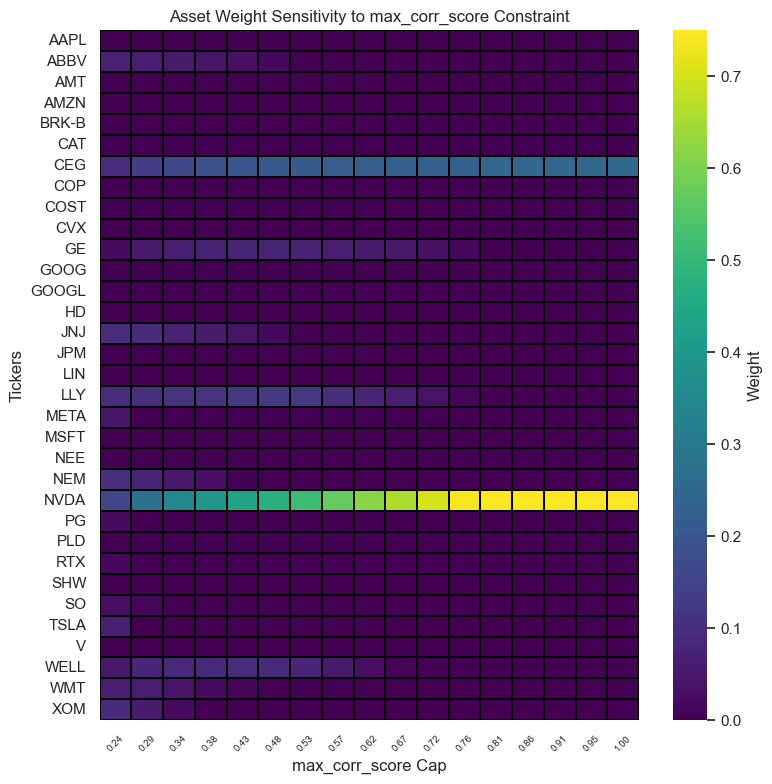

In [15]:
# ----------------------------------------------------
# WEIGHT HEATMAP FOR CORR_SCORE SENSITIVITY
# ----------------------------------------------------

weight_df_corr = pd.DataFrame(weights_corr, columns=tickers)
weight_df_corr["max_corr_score_limit"] = max_corr_grid
weight_df_corr = weight_df_corr.set_index("max_corr_score_limit")

# FIX: remove infeasible rows (all-NaN) that cause blank white columns
weight_df_corr = weight_df_corr.dropna(how="all")

plt.figure(figsize=(8, 8))
sns.heatmap(
    weight_df_corr.T,
    cmap="viridis",
    cbar_kws={"label": "Weight"},
    linewidths=0.2,
    linecolor="black"
)

plt.title("Asset Weight Sensitivity to max_corr_score Constraint")
plt.xlabel("max_corr_score Cap")
plt.ylabel("Tickers")

# Format x-axis to 2 decimals
plt.gca().set_xticklabels([f"{x:.2f}" for x in weight_df_corr.index], rotation=45, fontsize=7)

plt.tight_layout()
plt.show()

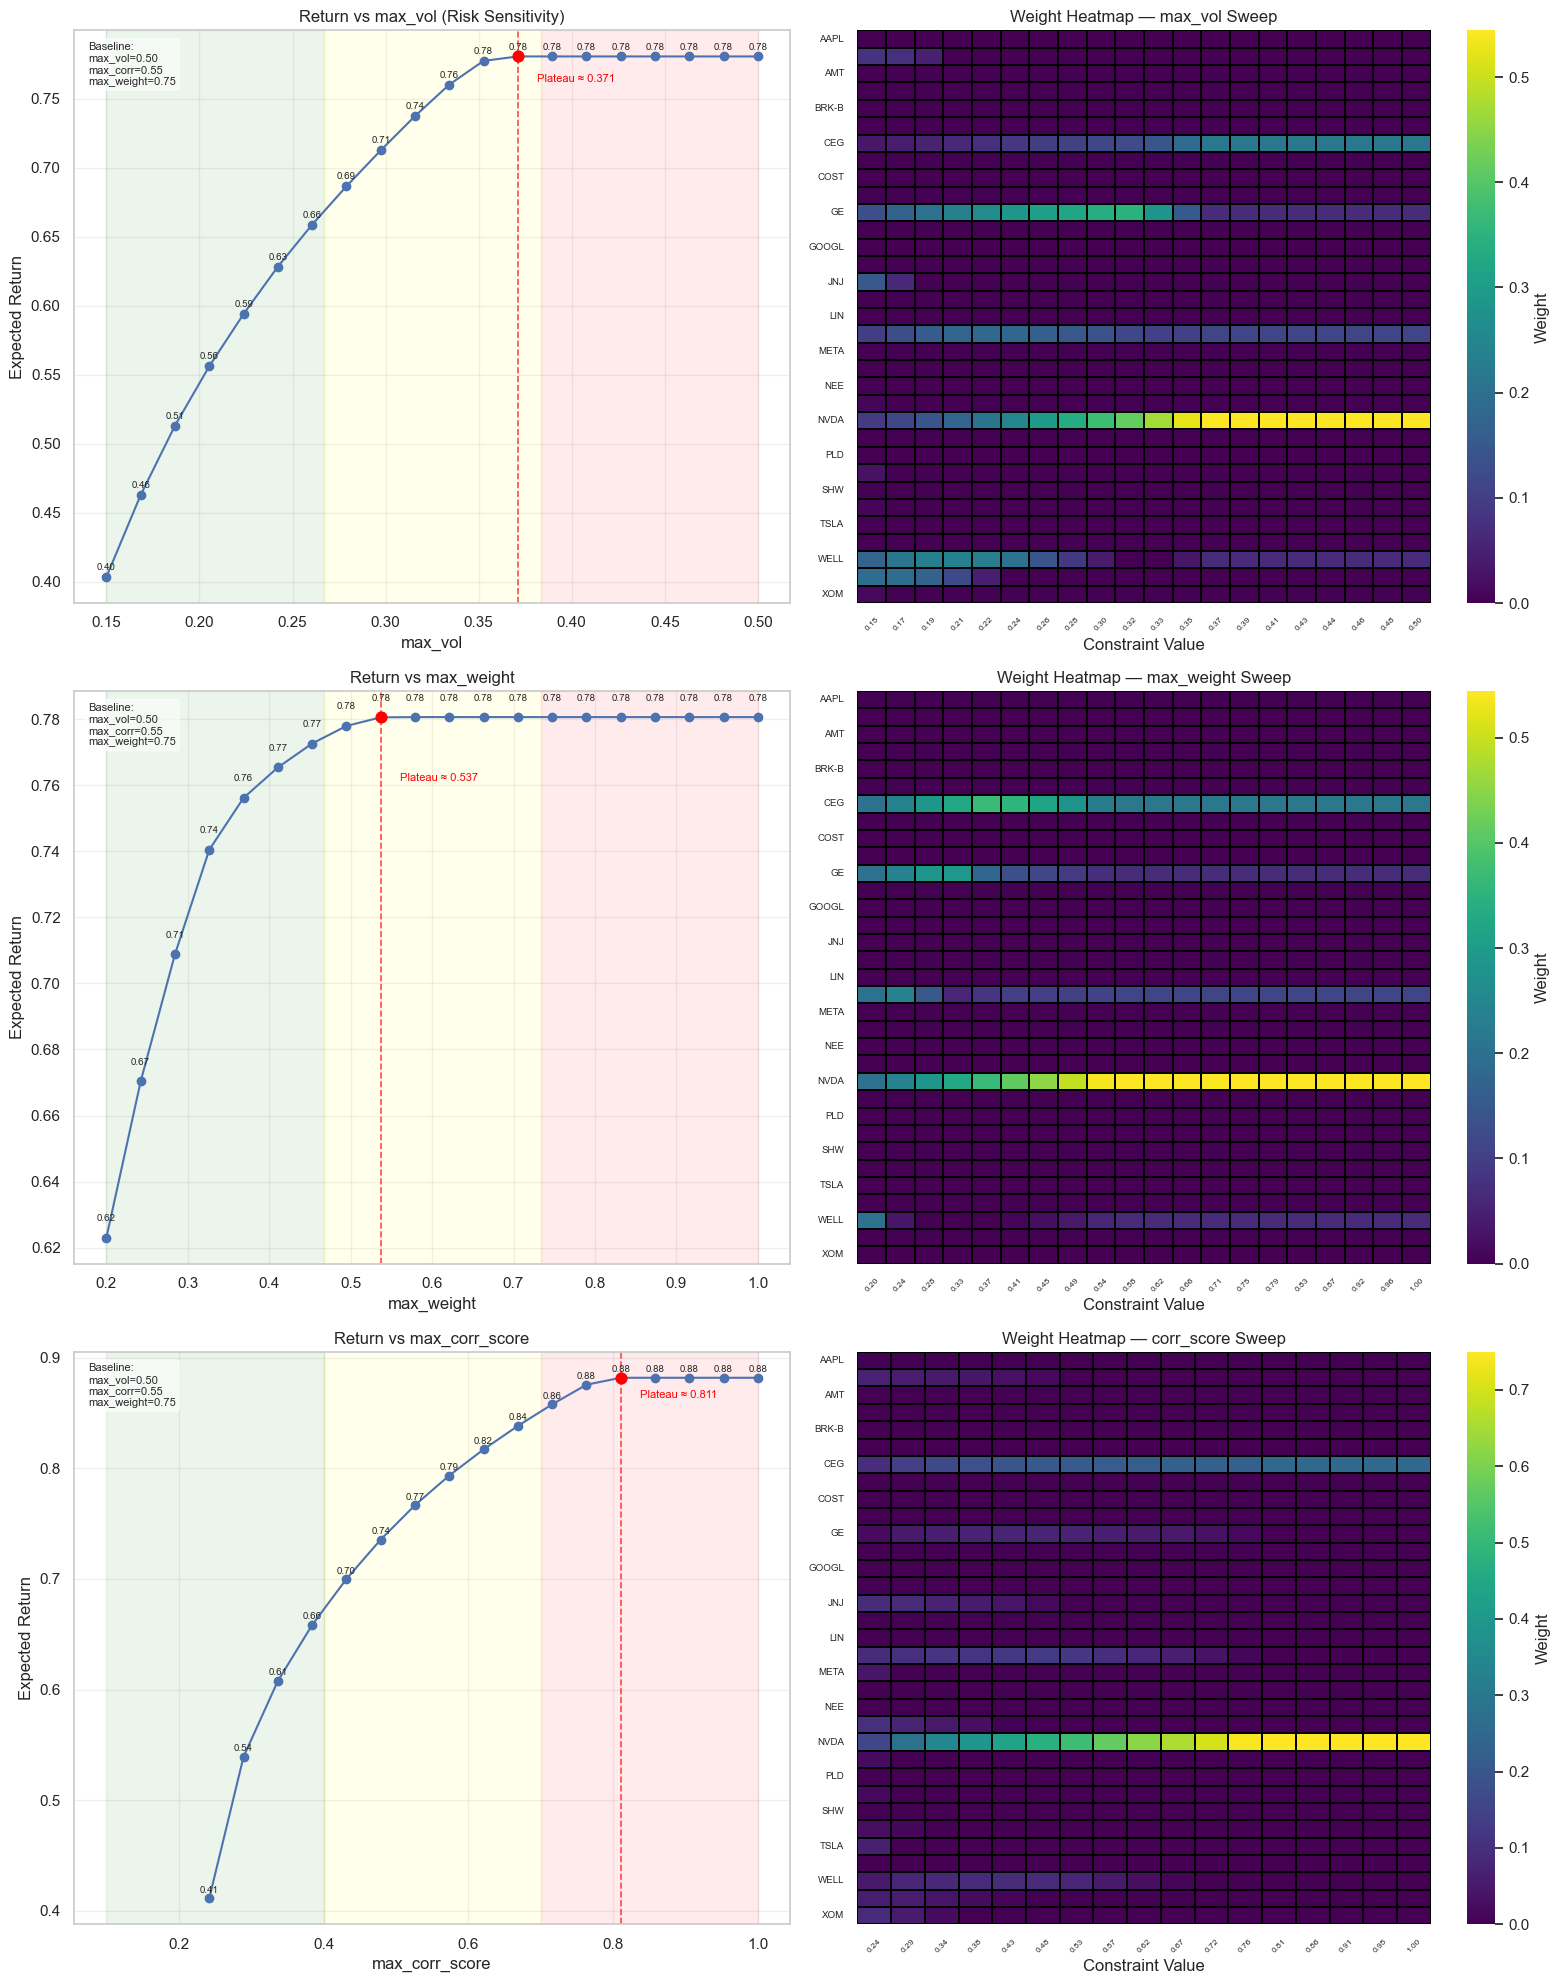

In [16]:
# ============================================================
#               3×2 SENSITIVITY ANALYSIS DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")


# ------------------------------------------------------------
# Helper: Plot return curve WITH plateau marking
# ------------------------------------------------------------
def plot_return_curve(ax, x, y, title, xlabel, BASE_SETTINGS):
    ax.plot(x, y, marker="o")

    # Add labels above dots
    for xv, yv in zip(x, y):
        if not np.isnan(yv):
            ax.text(xv, yv + 0.005, f"{yv:.2f}", ha="center", fontsize=7)

    # Shade 3 zones
    low, high = x.min(), x.max()
    cut1 = low + (high - low)/3
    cut2 = low + 2*(high - low)/3

    ax.axvspan(low,  cut1, color="green",  alpha=0.08)
    ax.axvspan(cut1, cut2, color="yellow", alpha=0.08)
    ax.axvspan(cut2, high, color="red",    alpha=0.08)

    # --------------------------------------------------------
    # Add plateau detection + plot marking
    # --------------------------------------------------------
    tol = 1e-4
    max_ret = np.nanmax(y)
    plateau_idx = np.where(max_ret - y <= tol)[0]

    if len(plateau_idx) > 0:
        plateau_x = x[plateau_idx[0]]
        plateau_y = y[plateau_idx[0]]

        # Vertical line at plateau
        ax.axvline(plateau_x, color="red", linestyle="--", linewidth=1.2, alpha=0.7)

        # Red dot marking the plateau point
        ax.scatter([plateau_x], [plateau_y], color="red", s=60, zorder=5)

        # Label for plateau
        ax.text(
            plateau_x + (x.max() - x.min()) * 0.03,
            plateau_y - 0.02,
            f"Plateau ≈ {plateau_x:.3f}",
            color="red",
            fontsize=8,
            ha="left",
            va="bottom"
        )

    # --------------------------------------------------------
    # Title and baseline box
    # --------------------------------------------------------
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Expected Return")
    ax.grid(True, alpha=0.3)

    # Baseline settings box
    ax.text(
        0.02, 0.98,
        f"Baseline:\n"
        f"max_vol={BASE_SETTINGS['max_vol']:.2f}\n"
        f"max_corr={BASE_SETTINGS['max_corr_score']:.2f}\n"
        f"max_weight={BASE_SETTINGS['max_weight']:.2f}",
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=8,
        bbox=dict(boxstyle="round", fc="white", alpha=0.6)
    )


# ------------------------------------------------------------
# Helper: Weight heatmap
# ------------------------------------------------------------

def plot_heatmap(ax, weights_list, grid, title):
    # rows = constraint values, cols = tickers
    weight_df = pd.DataFrame(weights_list, columns=tickers)
    weight_df["limit"] = grid
    weight_df = weight_df.set_index("limit")

    # Drop constraint levels that are completely infeasible (all NaN weights)
    weight_df = weight_df.dropna(how="all")

    sns.heatmap(
        weight_df.T,
        cmap="viridis",
        ax=ax,
        cbar_kws={"label": "Weight"},
        linewidths=0.15,
        linecolor="black"
    )

    ax.set_title(title)
    ax.set_xlabel("Constraint Value")
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
    ax.set_xticklabels([f"{x:.2f}" for x in weight_df.index], rotation=45, fontsize=6)


# ------------------------------------------------------------
# RUN ALL 3 SENSITIVITIES
# ------------------------------------------------------------
df_risk,   w_risk   = run_sensitivity("max_vol",        max_vol_grid)
df_weight, w_weight = run_sensitivity("max_weight",     max_weight_grid)
df_corr,   w_corr   = run_sensitivity("max_corr_score", max_corr_grid)


# ------------------------------------------------------------
# BUILD 3×2 PLOT GRID (no binding column)
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# -------- Row 1: Risk Sensitivity --------
plot_return_curve(
    axes[0,0], df_risk["max_vol_limit"], df_risk["return"],
    "Return vs max_vol (Risk Sensitivity)",
    "max_vol",
    BASE_SETTINGS
)
plot_heatmap(
    axes[0,1], w_risk, max_vol_grid,
    "Weight Heatmap — max_vol Sweep"
)

# -------- Row 2: Max Weight Sensitivity --------
plot_return_curve(
    axes[1,0], df_weight["max_weight_limit"], df_weight["return"],
    "Return vs max_weight",
    "max_weight",
    BASE_SETTINGS
)
plot_heatmap(
    axes[1,1], w_weight, max_weight_grid,
    "Weight Heatmap — max_weight Sweep"
)

# -------- Row 3: Corr Score Sensitivity --------
plot_return_curve(
    axes[2,0], df_corr["max_corr_score_limit"], df_corr["return"],
    "Return vs max_corr_score",
    "max_corr_score",
    BASE_SETTINGS
)
plot_heatmap(
    axes[2,1], w_corr, max_corr_grid,
    "Weight Heatmap — corr_score Sweep"
)

plt.tight_layout()
plt.show()


In [18]:
## Activity

def run_portfolio(max_vol, max_corr_score, max_weight=1.0):
    """
    Convenience wrapper to run the optimizer for a single portfolio profile.
    """
    w, ret, vol, corr_q = max_return_low_corr_markowitz(
        mu, cov, corr_mat,
        max_vol=max_vol,
        max_corr_score=max_corr_score,
        max_weight=max_weight
    )
    
    df = pd.DataFrame({
        "Ticker": tickers,
        "Weight": w
    }).sort_values("Weight", ascending=False).round({"Weight": 4})

    print("\n=========================================")
    print("PORTFOLIO OPTIMIZATION RESULT")
    print("=========================================")
    print(f"Return (mu^T w):           {ret: .2%}")
    print(f"Volatility (sqrt wΣw):     {vol: .2%} (limit {max_vol: .0%})")
    print(f"CorrScore (w^T C w):       {corr_q: .2f} (limit {max_corr_score: .2f})\n")
    
    print(df[df["Weight"] > 0.001])

    return {
        "weights": w,
        "return": ret,
        "vol": vol,
        "corr": corr_q,
        "df": df
    }

result = run_portfolio(
    max_vol=0.37,
    max_corr_score=0.881,
    max_weight=0.534  
)



PORTFOLIO OPTIMIZATION RESULT
Return (mu^T w):            80.20%
Volatility (sqrt wΣw):      37.00% (limit  37%)
CorrScore (w^T C w):        0.63 (limit  0.88)

   Ticker  Weight
22   NVDA   0.534
10     GE   0.274
6     CEG   0.192
